<div align="center">

# 🏋️‍♂️ AI Personal Trainer
### Smart Exercise Recommendation System

![Python](https://img.shields.io/badge/Python-3.8%2B-blue?style=for-the-badge&logo=python&logoColor=white)
![Machine Learning](https://img.shields.io/badge/Machine%20Learning-Random%20Forest-green?style=for-the-badge)
![Status](https://img.shields.io/badge/Status-Active-orange?style=for-the-badge)

<img src="https://images.unsplash.com/photo-1534438327276-14e5300c3a48?w=1200&h=400&fit=crop" alt="Fitness Banner" width="100%" style="border-radius: 10px;"/>

</div>

---

## 📋 Table of Contents
1. [**Introduction & Objective**](#introduction)
2. [**Dataset Snapshot**](#dataset)
3. [Exploratory Data Analysis (EDA)](#eda)
4. [Feature Engineering & Preprocessing](#features)
5. [Model Comparison & Selection](#modeling)
6. [Recommendation Engine Logic](#recommendation)
7. [Final Results & Demo](#results)

---

<a id='introduction'></a>
## 🎯 Introduction & Objective

> *"Finding the right exercise is easy. Finding the **most efficient** exercise for your specific goals is the challenge."*

Whether you have a fully equipped gym or just a pair of dumbbells, optimizing your workout for maximum caloric burn can be a guessing game. This project removes the guesswork by building an **AI-Powered Exercise Recommendation Engine**.

### 💡 The Solution
Instead of generic advice, this system uses **Machine Learning** to:
1.  **🔍 Filter** a massive library of exercises based on your specific constraints (e.g., *Intermediate level, Back workout, Dumbbells only*).
2.  **🧠 Predict** the exact caloric expenditure for each matching exercise.
3.  **🏆 Rank** and suggest the top 5 most efficient movements for you.

### Why It Matters
* **Smart Planning:** Transitions fitness from "feeling" to "data-driven."
* **Efficiency:** Maximizes results per minute spent working out.
* **Adaptability:** Dynamically adjusts recommendations based on available equipment and skill level.

---

<a id='dataset'></a>
## 📊 Dataset Snapshot

This project is powered by the **Life Style Data** dataset, a robust collection of fitness metrics sourced from Kaggle.

* **📂 Source:** `jockeroika/life-style-data`
* **📏 Size:** 20,000 Rows, 54 Columns
* **🧪 Type:** Structured Tabular Data

### 🗝️ Key Features
We extracted specific features to train our predictive model:

| **Feature Category** | **Description** |
| :--- | :--- |
| **🔥 Target Variable** | `Burns Calories (per 30 min)` |
| **💪 Intensity** | `Sets` (3-5), `Reps` (5-30) |
| **🏷️ Categorical** | `Target Muscle Group`, `Equipment Needed`, `Difficulty Level` |
| **🧬 Anatomical** | `Body Part`, `Type of Muscle`, `Benefit` |

##STEP 1 — Load Dataset from Kaggle + Basic Cleaning


###a. Import Kaggle dataset

In [1]:
# IMPORTANT: RUN THIS CELL TO IMPORT KAGGLE DATASET

import kagglehub

# Download the dataset from Kaggle
dataset_path = kagglehub.dataset_download("jockeroika/life-style-data")

print(" Dataset downloaded successfully!")
print(" Path:", dataset_path)


100%|██████████| 3.81M/3.81M [00:00<00:00, 102MB/s]

Extracting files...
 Dataset downloaded successfully!
 Path: /root/.cache/kagglehub/datasets/jockeroika/life-style-data/versions/7


###b. Import Libraries

In [2]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Simple clean style for plots
sns.set(style="whitegrid")


###b. Load the CSV File

In [3]:
# Build full path to the CSV file
csv_path = os.path.join(dataset_path, "Final_data.csv")

# Load the dataset
df = pd.read_csv(csv_path)

# Look at first few rows
df.head()


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


###c. Basic Info (Shape + dtypes)

In [4]:
print("Dataset shape (rows, columns):", df.shape)
print("\nBasic Info:\n")
df.info()


Dataset shape (rows, columns): (20000, 54)

Basic Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           2000

### Feature Types in the Dataset

| Category              | Features Included |
|----------------------|------------------|
| **Demographics**     | Age, Gender, Weight, Height, BMI |
| **Physiological Data** | Max_BPM, Avg_BPM, Resting_BPM, Fat_Percentage, Water_Intake |
| **Exercise Metrics** | Session_Duration, Calories_Burned, Workout_Type, Workout_Frequency |
| **Exercise Specifics** | Name of Exercise, Sets, Reps, Benefit, Equipment Needed, Difficulty Level, Target Muscle Group |
| **Nutrition & Lifestyle** | Daily Meals Frequency, Carbs, Proteins, Fats, Water Intake |


###d. Check Missing Values

In [5]:
# Count of missing values in each column
df.isnull().sum()
# Percentage of missing values
missing_percent = (df.isnull().mean() * 100).round(2)
missing_percent


,0
Age,0.0
Gender,0.0
Weight (kg),0.0
Height (m),0.0
Max_BPM,0.0
Avg_BPM,0.0
Resting_BPM,0.0
Session_Duration (hours),0.0
Calories_Burned,0.0
Workout_Type,0.0


### e. Simple Cleaning (Very Basic & Clear)

We keep cleaning simple:

- **Remove exact duplicate rows**
- **Fill missing numeric values** with mean
- **Fill missing text values** with empty string

In [6]:
# 1) Drop duplicate rows
before_rows = df.shape[0]
df = df.drop_duplicates()
after_rows = df.shape[0]

print(f"Removed {before_rows - after_rows} duplicate rows")

# 2) Fill missing numeric values with column mean
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# 3) Fill missing text (object) values with empty string
text_cols = df.select_dtypes(include=["object"]).columns
df[text_cols] = df[text_cols].fillna("")

print("Missing values handled (numeric → mean, text → empty string)")


Removed 0 duplicate rows
Missing values handled (numeric → mean, text → empty string)


###f. Summary Statistics

In [7]:
df.describe()


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),...,BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04
mean,38.851453,73.898832,1.723093,179.889702,143.704306,62.195813,1.259446,1280.109600,26.101313,2.627485,...,24.921651,1998.297076,0.499983,1.460142,0.699005,0.802305,744.308699,53.786384,866.352318,8.631802e+19
std,12.114580,21.173010,0.127033,11.510805,14.267688,7.289351,0.341336,502.228982,4.996160,0.604724,...,6.701144,440.848408,0.001455,0.518946,0.144880,0.096613,720.946619,12.498740,250.317069,3.197579e+19
min,18.000000,39.180000,1.490000,159.310000,119.070000,49.490000,0.490000,323.110000,11.333134,1.460000,...,12.037907,1105.570000,0.492434,0.516706,0.371344,0.599789,-1266.220000,30.946261,219.852800,2.491905e+16
25%,28.170000,58.160000,1.620000,170.057500,131.220000,55.960000,1.050000,910.800000,22.387807,2.170000,...,20.094975,1661.022500,0.499054,1.076294,0.583656,0.727676,261.432500,44.587037,714.098250,6.441978e+19
50%,39.865000,70.000000,1.710000,180.140000,142.990000,62.200000,1.270000,1231.450000,25.822504,2.610000,...,24.119097,1943.130000,0.499981,1.382260,0.686284,0.794834,691.190000,51.204908,868.721400,8.371578e+19
75%,49.630000,86.100000,1.800000,189.425000,156.060000,68.090000,1.460000,1553.112500,29.676026,3.120000,...,28.562620,2271.950000,0.500910,1.750495,0.798196,0.869211,1176.290000,61.939016,1012.532700,1.100442e+20
max,59.670000,130.770000,2.010000,199.640000,169.840000,74.500000,2.020000,2890.820000,35.000000,3.730000,...,50.229544,3699.540000,0.507889,3.916881,1.073939,1.047032,3075.580000,90.117371,1477.108800,1.756614e+20


### Step 1: Conclusion — Dataset Overview & Readiness

- The Kaggle dataset consists of **20,000 records and 54 features**, offering a strong and reliable base for machine learning.  
- All missing values were successfully handled (numeric → mean, text → empty string), resulting in **0% missing data**.  
- A duplicate check confirmed **no repeated rows**, ensuring high data integrity.  
- The feature set is highly diverse, covering **demographics, physiological metrics, lifestyle and nutrition details, workout information, and exercise-specific attributes**.  
- Summary statistics show realistic and healthy user patterns — average age ~39 years, BMI ~25, resting BPM ~62, and average calories burned ~1280 per session.  
- Overall, the dataset is **clean, complete, and well-prepared**, making it fully ready for exploratory analysis, feature engineering, and model development.


##STEP 2 — Explore Data & Understand Important Features

###a. Check Shape & Column Names

In [8]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
df.columns.tolist()


Shape of dataset: (20000, 54)

Column names:


['Age',
 'Gender',
 'Weight (kg)',
 'Height (m)',
 'Max_BPM',
 'Avg_BPM',
 'Resting_BPM',
 'Session_Duration (hours)',
 'Calories_Burned',
 'Workout_Type',
 'Fat_Percentage',
 'Water_Intake (liters)',
 'Workout_Frequency (days/week)',
 'Experience_Level',
 'BMI',
 'Daily meals frequency',
 'Physical exercise',
 'Carbs',
 'Proteins',
 'Fats',
 'Calories',
 'meal_name',
 'meal_type',
 'diet_type',
 'sugar_g',
 'sodium_mg',
 'cholesterol_mg',
 'serving_size_g',
 'cooking_method',
 'prep_time_min',
 'cook_time_min',
 'rating',
 'Name of Exercise',
 'Sets',
 'Reps',
 'Benefit',
 'Burns Calories (per 30 min)',
 'Target Muscle Group',
 'Equipment Needed',
 'Difficulty Level',
 'Body Part',
 'Type of Muscle',
 'Workout',
 'BMI_calc',
 'cal_from_macros',
 'pct_carbs',
 'protein_per_kg',
 'pct_HRR',
 'pct_maxHR',
 'cal_balance',
 'lean_mass_kg',
 'expected_burn',
 'Burns Calories (per 30 min)_bc',
 'Burns_Calories_Bin']

### b. Basic Distribution of Key Exercise Features

* To visualize the data distribution of the numerical features.

* To check if the data follows a normal distribution (bell curve) or if it is skewed (leaning to one side).

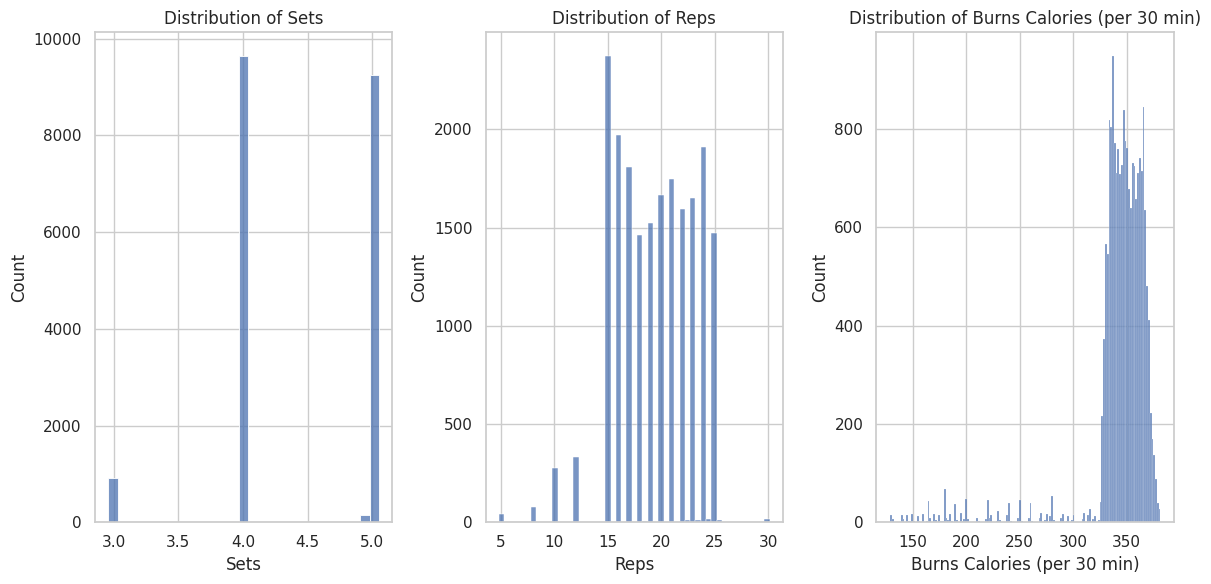

In [9]:
key_exercise_cols = [
    "Sets",
    "Reps",
    "Burns Calories (per 30 min)"
]

plt.figure(figsize=(12, 6))

for i, col in enumerate(key_exercise_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=False) #histogram
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


###Conclusion  

The analysis confirms that:

- **Sets** values fall within realistic human workout ranges (typically **3–5 sets**).  
- **Reps** also lie within a natural workout range (**5–30 reps**).  
- The target variable, **Burns Calories**, shows **sufficient variance**, meaning a machine learning model can effectively learn patterns from it.

Overall, the dataset appears **valid, realistic, and suitable for predictive modeling**.


### c. Boxplots (Outlier Check)

* To identify outliers (extreme values) in the target variable.

* To visualize the median, interquartile range (25th to 75th percentile), and minimum/maximum values.

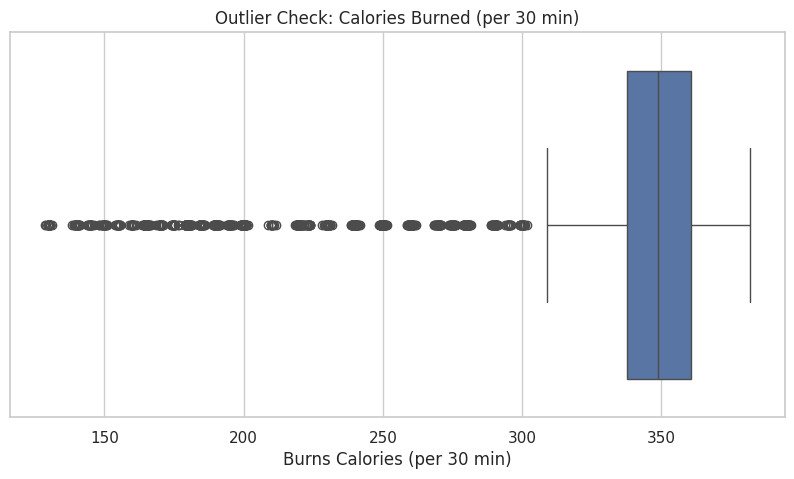

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Burns Calories (per 30 min)"])
plt.title("Outlier Check: Calories Burned (per 30 min)")
plt.xlabel("Burns Calories (per 30 min)")
plt.show()


### Conclusion / Insight

- The boxplot helps detect unrealistic calorie-burn values that could distort model training.  
- Most data points fall in a reasonable range with only a few low-calorie outliers.  
- These outliers represent lighter exercises, not errors.  
- No impossible or extreme values appear in the dataset, so the calorie feature is suitable for modeling.


### d. Countplots for Categorical Features

We visualize:

* Difficulty Level

* Target Muscle Group

* Equipment Needed

Why??
* To check for data imbalance.

* To ensure the dataset has a good variety of exercises across different categories

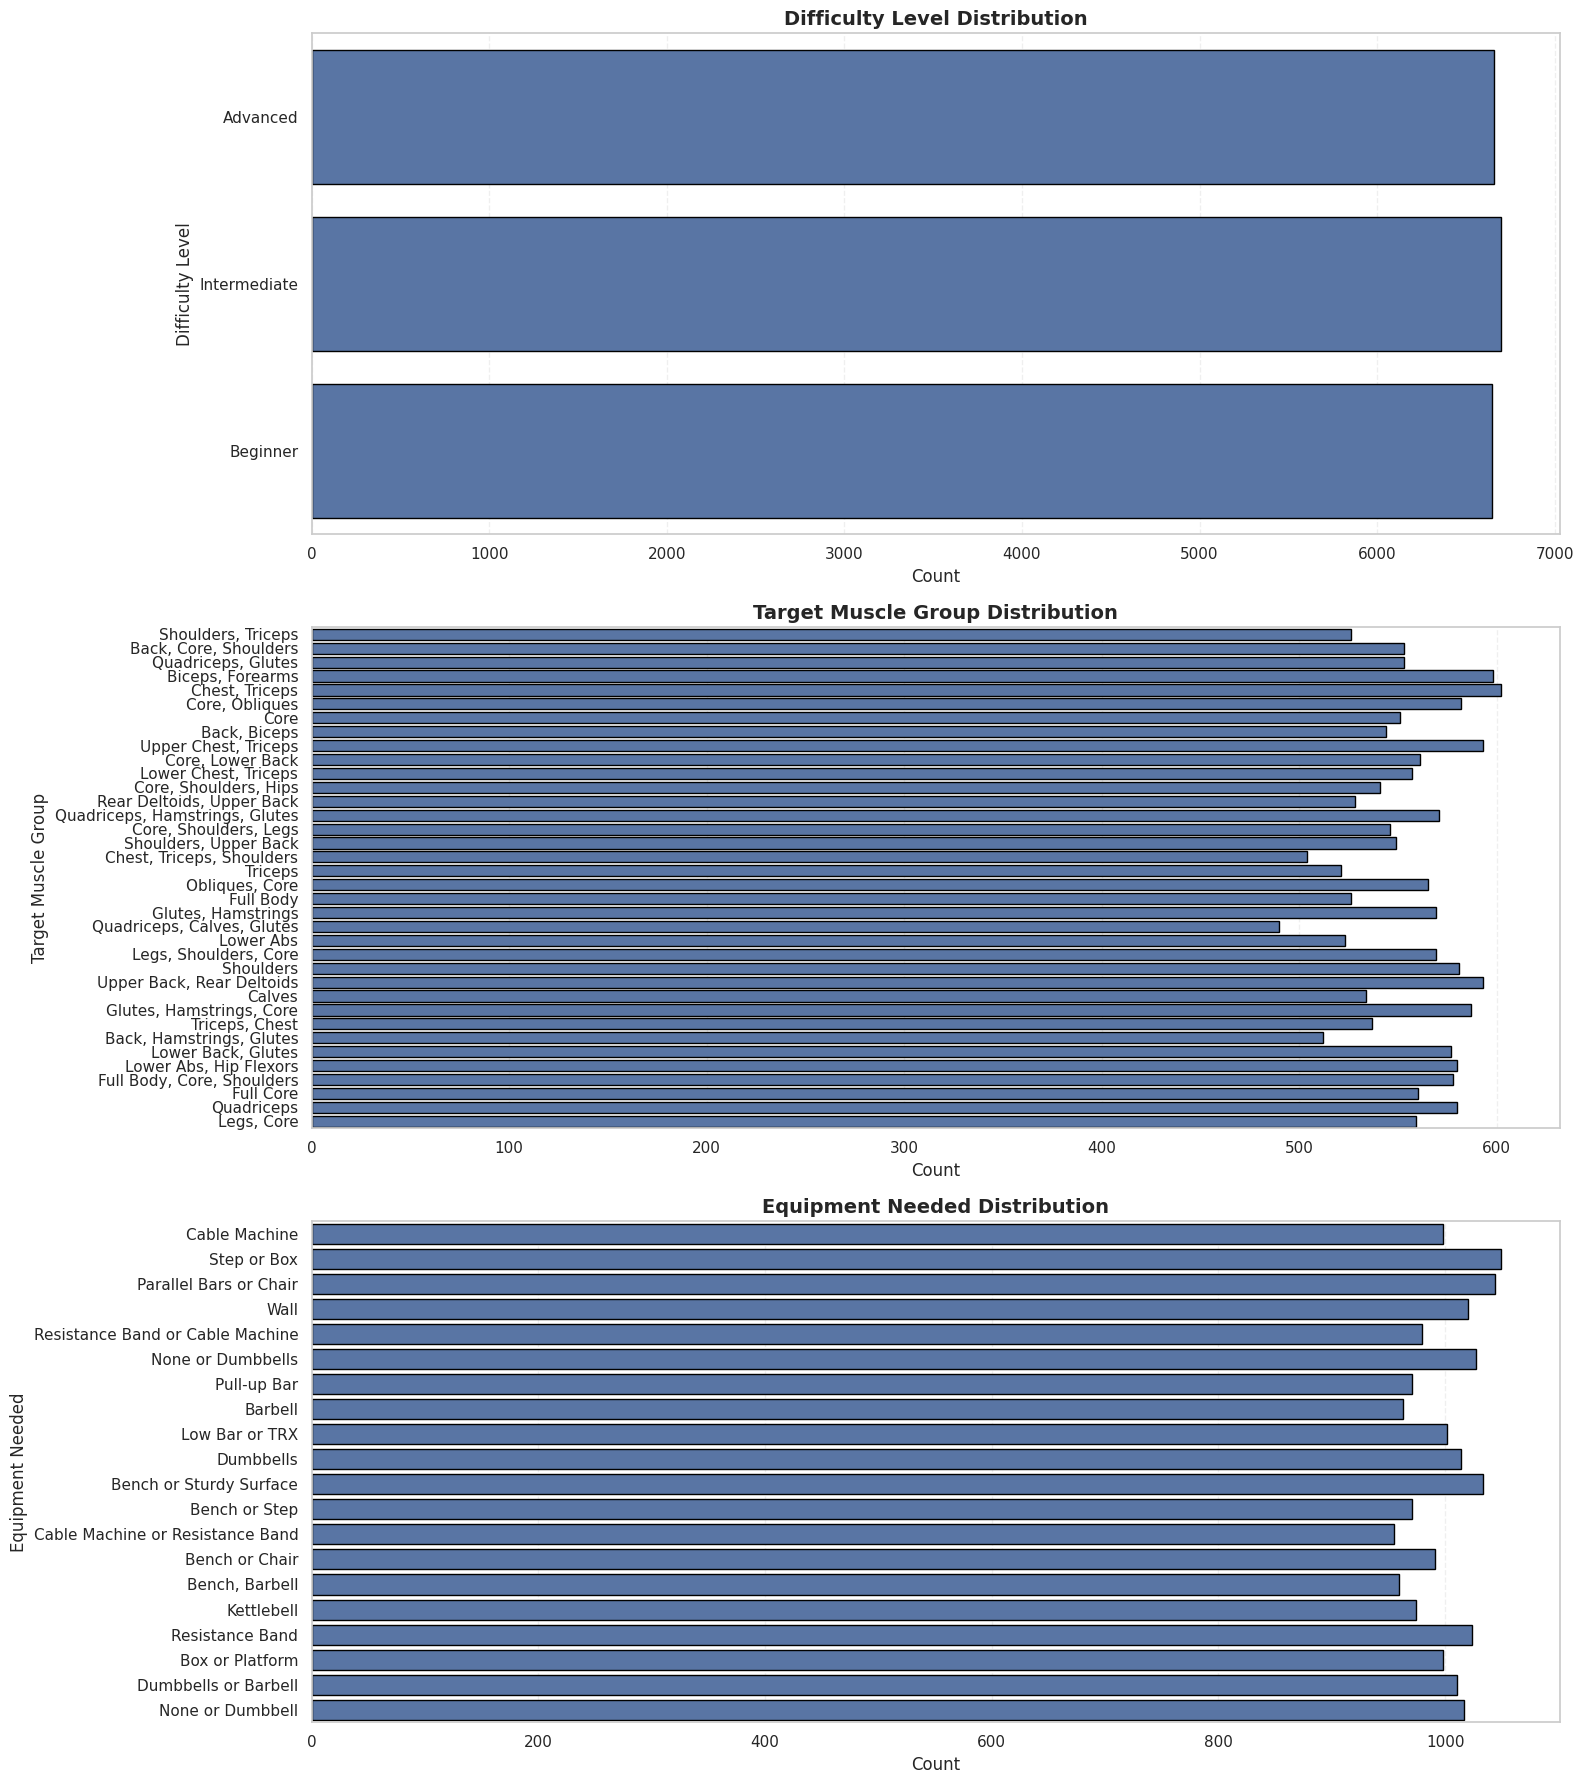

In [11]:
cat_plots = [
    "Difficulty Level",
    "Target Muscle Group",
    "Equipment Needed"
]

plt.figure(figsize=(16, 18))

for i, col in enumerate(cat_plots, 1):
    plt.subplot(3, 1, i)
    sns.countplot(data=df, y=col, edgecolor="black") #Barchart
    plt.title(f"{col} Distribution", fontsize=14, fontweight="bold")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


### Conclusion / Insight

- These distributions show how evenly different exercise categories are represented.  
- Difficulty levels (Beginner, Intermediate, Advanced) appear balanced, meaning the model can learn fairly across all skill levels.  
- Target muscle groups and equipment types also show wide coverage, ensuring the recommendation system can suggest diverse workouts.  
- No single category is severely underrepresented, so the dataset is suitable for building a well-rounded exercise recommendation model.


###e. Heatmap

Why??
* To quantify the linear relationship between numeric variables ("Sets", "Reps", and "Burns Calories").

* To see which input features have the strongest influence on the target variable.

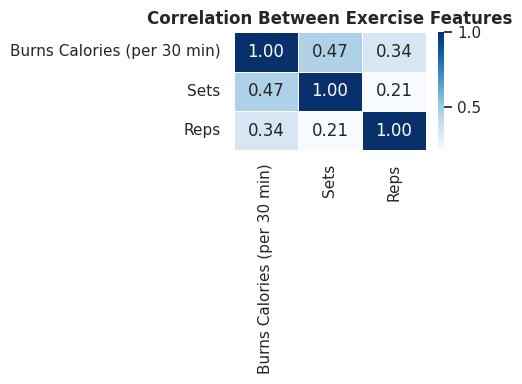

In [12]:
# Perfect Clean Heatmap for Exercise Features

# Select ONLY numeric exercise-related columns
exercise_numeric = df[[
    "Burns Calories (per 30 min)",
    "Sets",
    "Reps"
]]

# Compute correlation
corr_ex = exercise_numeric.corr()

# Plot heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(corr_ex, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Exercise Features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


###Conclusion / Insight

- The heatmap shows how strongly Sets and Reps relate to calorie burn.  
- Both features have **moderate positive correlations** with calories (Sets: 0.47, Reps: 0.34).  
- This means higher intensity generally leads to higher calorie burn, but not perfectly.  
- These correlations are strong enough to confirm that Sets and Reps are **useful predictors** for the calorie prediction model.


##STEP 3 — Create Exercise Dataset + Select Features for Modeling

### a. Create a Pure Exercise DataFrame

In [34]:
# STEP 3 — a. Create a Pure Exercise DataFrame

exercise_cols = [
    "Name of Exercise",
    "Sets",
    "Reps",
    "Benefit",
    "Burns Calories (per 30 min)",
    "Target Muscle Group",
    "Equipment Needed",
    "Difficulty Level",
    "Body Part",
    "Type of Muscle",
]

# Keep only these columns and drop missing rows
df_ex = df[exercise_cols].dropna().copy()

print("Total rows in Exercise Dataset:", len(df_ex))
df_ex.head()

Total rows in Exercise Dataset: 20000


,Name of Exercise,Sets,Reps,Benefit,Burns Calories (per 30 min),Target Muscle Group,Equipment Needed,Difficulty Level,Body Part,Type of Muscle
0,Decline Push-ups,4.99,20.91,Improves shoulder health and posture,342.58,"Shoulders, Triceps",Cable Machine,Advanced,Legs,Lats
1,Bear Crawls,4.01,16.15,Strengthens lower abs,357.16,"Back, Core, Shoulders",Step or Box,Intermediate,Chest,Lats
2,Dips,5.00,21.90,Builds chest strength,359.63,"Quadriceps, Glutes",Step or Box,Intermediate,Arms,Grip Strength
3,Mountain Climbers,4.01,16.92,Improves coordination and cardiovascular health,351.65,"Biceps, Forearms",Parallel Bars or Chair,Advanced,Shoulders,Upper
4,Bicep Curls,4.99,15.01,Targets obliques and improves core rotation,329.36,"Chest, Triceps",Wall,Advanced,Abs,Wrist Flexors


### b. Select Features for the Exercise Recommendation Model

We need:

* Target: Burns Calories (per 30 min)

* Features: all remaining columns

In [35]:
# STEP 3 — b. Select Features for the Exercise Recommendation Model

target_col = "Burns Calories (per 30 min)"

# Exclude target and exercise name from features
feature_cols = [col for col in df_ex.columns if col not in ["Name of Exercise", target_col]]

print("Features used for model:")
print(feature_cols)

print("\nTarget column:", target_col)

Features used for model:
['Sets', 'Reps', 'Benefit', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle']

Target column: Burns Calories (per 30 min)


### c. Define X and y (Feature Matrix & Target Vector)

In [36]:
# STEP 3 — c. Define X and y (feature matrix & target vector)

X = df_ex[feature_cols]
y = df_ex[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 8)
y shape: (20000,)


### d. Encode Categorical Features

In [16]:
# STEP 3 — d. Encode Categorical Features

# Identify categorical and numeric columns
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", list(cat_cols))
print("Numeric columns:", list(num_cols))

# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("\nShape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)


Categorical columns: ['Benefit', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle']
Numeric columns: ['Sets', 'Reps']

Shape before encoding: (20000, 8)
Shape after encoding: (20000, 124)


##STEP 4 — Train Models to Predict Calories Burned

###a. Define Features (X) and Target (y)

In [37]:
# STEP 4 — a. Define Features (X) and Target (y)

target_col = "Burns Calories (per 30 min)"

# All columns except the target are features
feature_cols = [col for col in df_ex.columns if col != target_col]

X = df_ex[feature_cols].copy()
y = df_ex[target_col].copy()

print("Feature columns:")
print(feature_cols)

print("\nTarget column:")
print(target_col)

X.head()

Feature columns:
['Name of Exercise', 'Sets', 'Reps', 'Benefit', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle']

Target column:
Burns Calories (per 30 min)


,Name of Exercise,Sets,Reps,Benefit,Target Muscle Group,Equipment Needed,Difficulty Level,Body Part,Type of Muscle
0,Decline Push-ups,4.99,20.91,Improves shoulder health and posture,"Shoulders, Triceps",Cable Machine,Advanced,Legs,Lats
1,Bear Crawls,4.01,16.15,Strengthens lower abs,"Back, Core, Shoulders",Step or Box,Intermediate,Chest,Lats
2,Dips,5.00,21.90,Builds chest strength,"Quadriceps, Glutes",Step or Box,Intermediate,Arms,Grip Strength
3,Mountain Climbers,4.01,16.92,Improves coordination and cardiovascular health,"Biceps, Forearms",Parallel Bars or Chair,Advanced,Shoulders,Upper
4,Bicep Curls,4.99,15.01,Targets obliques and improves core rotation,"Chest, Triceps",Wall,Advanced,Abs,Wrist Flexors


###b. Encode Categorical Features + Train–Test Split

In [18]:
# STEP 4 — b. Encode Categorical Features + Train–Test Split

from sklearn.model_selection import train_test_split

# Identify categorical vs numeric columns
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", list(cat_cols))
print("Numeric columns:", list(num_cols))

# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("\nShape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Categorical columns: ['Name of Exercise', 'Benefit', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle']
Numeric columns: ['Sets', 'Reps']

Shape before encoding: (20000, 9)
Shape after encoding: (20000, 178)

Train shape: (16000, 178)
Test shape: (4000, 178)


###c. Scale Features

In [19]:
# STEP 4 — c. Scale Features (for Linear Regression)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Scaled train shape: (16000, 178)
Scaled test shape: (4000, 178)


###d. Import and Train Multiple Models

In [20]:
# STEP 4 — d. Import and Train Multiple Models

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model 1 — Linear Regression (use scaled features)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Model 2 — Random Forest Regressor (tree models don't need scaling)
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Model 3 — Gradient Boosting Regressor
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)


GradientBoostingRegressor(random_state=42)

###e. Evaluate and Compare Models

In [21]:
# STEP 4 — e. Evaluate and Compare Models

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test, scaled=False):
    """
    scaled=True is only for linear regression where we use scaled features.
    """
    y_pred_test = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2 = r2_score(y_test, y_pred_test)
    return rmse, r2

# Linear Regression (scaled features)
lr_rmse, lr_r2 = evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test, scaled=True)

# Random Forest (unscaled)
rf_rmse, rf_r2 = evaluate_model(rf, X_train, X_test, y_train, y_test)

# Gradient Boosting (unscaled)
gb_rmse, gb_r2 = evaluate_model(gb, X_train, X_test, y_train, y_test)

results_ex = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [lr_rmse, rf_rmse, gb_rmse],
    "R2 Score": [lr_r2, rf_r2, gb_r2],
})

results_ex


,Model,RMSE,R2 Score
0,Linear Regression,26.161181,0.236428
1,Random Forest,16.533845,0.695012
2,Gradient Boosting,16.237115,0.705861


###f. Visual Comparison (Bar Plots)

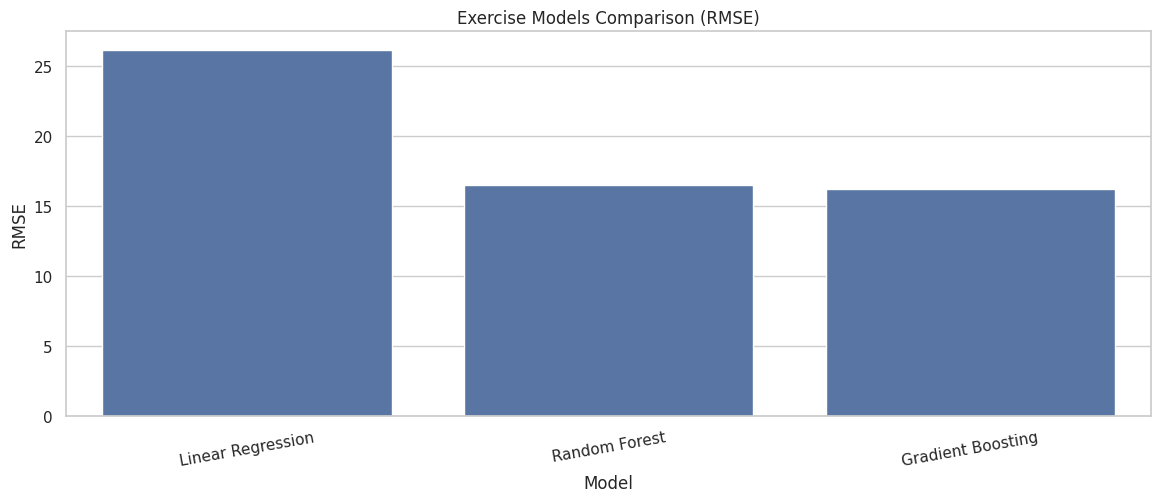

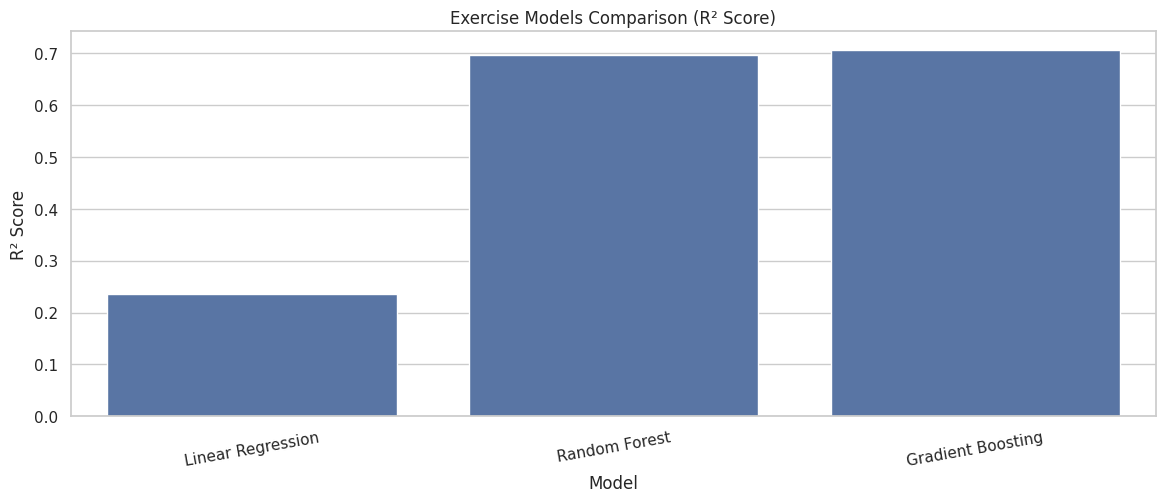

Best Exercise Model (by RMSE): Gradient Boosting
RMSE: 16.2371
R² : 0.7059


In [22]:
# STEP 4 — f. Visual Comparison (Bar Plots)

plt.figure(figsize=(14, 5))
sns.barplot(data=results_ex, x="Model", y="RMSE")
plt.title("Exercise Models Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=10)
plt.show()

plt.figure(figsize=(14, 5))
sns.barplot(data=results_ex, x="Model", y="R2 Score")
plt.title("Exercise Models Comparison (R² Score)")
plt.ylabel("R² Score")
plt.xticks(rotation=10)
plt.show()

best_row_ex = results_ex.loc[results_ex["RMSE"].idxmin()]
print("Best Exercise Model (by RMSE):", best_row_ex["Model"])
print(f"RMSE: {best_row_ex['RMSE']:.4f}")
print(f"R² : {best_row_ex['R2 Score']:.4f}")


### ✔️ Conclusion / Insight

- The model comparison clearly shows that **tree-based algorithms outperform Linear Regression**.  
- **Random Forest** and **Gradient Boosting** deliver significantly lower RMSE (16) than Linear Regression (26), indicating far better accuracy.  
- This suggests that calorie burn does **not follow a simple linear pattern**, and non-linear models capture the relationships more effectively.  
- Therefore, **Gradient Boosting or Random Forest** is the most reliable choice for the final calorie-prediction system.


##STEP 5 — Train Final Model + Print Metrics (RMSE & R²)

### Final Conclusion

Random Forest and Gradient Boosting both perform far better than Linear Regression.  
However, **Random Forest is the safer and more practical choice** because:

- It is more robust against noise and overfitting.  
- It works well without heavy hyperparameter tuning.  
- It trains faster due to parallel tree building.  
- It often generalizes better on smaller datasets.

**Therefore, Random Forest is the most reliable model for the final calorie-prediction system.**


### a. Train the Best Model Again (Random Forest)

In [23]:
# STEP 5 — a. Train the Best Model Again (Random Forest)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Final model for Exercise Recommendation
rf_final_ex = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train on training data
rf_final_ex.fit(X_train, y_train)

# Predict on test set
y_pred_ex = rf_final_ex.predict(X_test)

# Metrics
rmse_ex = np.sqrt(mean_squared_error(y_test, y_pred_ex))
r2_ex = r2_score(y_test, y_pred_ex)

print("Final Random Forest Performance on Test Set")
print("-" * 50)
print(f"RMSE : {rmse_ex:.4f}")
print(f"R²   : {r2_ex:.4f}")


Final Random Forest Performance on Test Set
--------------------------------------------------
RMSE : 16.5545
R²   : 0.6943


### b. Retrain on FULL DATA for Deployment

In [38]:
# STEP 5 — b. Retrain on FULL DATA for Deployment

# Use the entire encoded dataset
X_full = X_encoded.copy()                 # All exercise features encoded
y_full = df_ex[target_col].copy()            # All target values

print("X_full shape:", X_full.shape)
print("y_full shape:", y_full.shape)

rf_final_full_ex = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_final_full_ex.fit(X_full, y_full)

print("Final Exercise Model (rf_final_full_ex) trained on full data.")

X_full shape: (20000, 178)
y_full shape: (20000,)
Final Exercise Model (rf_final_full_ex) trained on full data.


STEP 6 — Build the Exercise Recommendation System

###a. Predict calories for a single exercise

In [39]:
# a. Predict calories for a single exercise row

def predict_exercise_calories(ex_row):
    """
    Predict calories burned for a single exercise row.
    ex_row = ONE-row DataFrame (original df_ex columns)
    """
    # The model was trained with 'Name of Exercise' as a feature, so we need to include it
    # in the row for encoding. X global variable stores the features used during training.
    model_training_features = X.columns.tolist()

    # Select only these features from the input ex_row
    row_for_encoding = ex_row[model_training_features]

    # One-hot encode using the global `cat_cols` (which includes 'Name of Exercise' from X)
    row_encoded = pd.get_dummies(row_for_encoding, columns=cat_cols, drop_first=True)

    # Align with training feature space (X_full is the X_encoded from full data)
    row_encoded = row_encoded.reindex(columns=X_full.columns, fill_value=0)

    # Predict calories
    pred = rf_final_full_ex.predict(row_encoded)[0]
    return pred

###b. Filter Exercises (based on user-selected options)

In [40]:
def apply_exercise_filters(
    df_exercise_data, # Changed parameter name from df_ex to df_exercise_data to avoid confusion with the global df_ex
    difficulty=None,
    muscle_group=None,
    equipment=None,
    body_part=None
):
    filtered_df = df_exercise_data.copy()

    if difficulty:
        filtered_df = filtered_df[filtered_df["Difficulty Level"] == difficulty]

    if muscle_group:
        filtered_df = filtered_df[
            filtered_df["Target Muscle Group"].str.contains(muscle_group, case=False)
        ]

    if equipment:
        filtered_df = filtered_df[
            filtered_df["Equipment Needed"].str.contains(equipment, case=False)
        ]

    if body_part:
        filtered_df = filtered_df[filtered_df["Body Part"] == body_part]

    return filtered_df

### c. Main Recommendation Function

In [41]:
# STEP 6 — c. Main Exercise Recommendation Function

def recommend_exercises(
    difficulty=None,
    muscle_group=None,
    equipment=None,
    body_part=None,
    top_n=5
):
    # 1. Filter dataset
    filtered_df = apply_exercise_filters(
        df_ex, # Use df_ex here
        difficulty=difficulty,
        muscle_group=muscle_group,
        equipment=equipment,
        body_part=body_part
    )

    if filtered_df.empty:
        return "No exercises match your filters."

    # 2. Predict calories for each exercise
    preds = []
    for idx, row in filtered_df.iterrows():
        pred_cal = predict_exercise_calories(row.to_frame().T)
        preds.append(pred_cal)

    filtered_df = filtered_df.copy()
    filtered_df["predicted_calories"] = preds

    # 3. Sort by predicted calories (High → Low)
    recommended = filtered_df.sort_values("predicted_calories", ascending=False).head(top_n)

    return recommended[[
        "Name of Exercise",
        "Sets",
        "Reps",
        "Difficulty Level",
        "Equipment Needed",
        "Target Muscle Group",
        "predicted_calories"
    ]]

###PREDICITION

In [46]:
recommend_exercises(
    difficulty="Intermediate",
    muscle_group="Back",
    equipment="Dumbbells",
    body_part="Back",
    top_n=5
)


,Name of Exercise,Sets,Reps,Difficulty Level,Equipment Needed,Target Muscle Group,predicted_calories
5805,Kettlebell Swings,4.00,14.97,Intermediate,None or Dumbbells,"Core, Lower Back",357.328067
9797,Windshield Wipers,4.01,19.04,Intermediate,None or Dumbbells,"Back, Biceps",357.248700
17084,Prone Cobras,4.00,15.02,Intermediate,Dumbbells or Barbell,"Core, Lower Back",354.321367
15193,Plyo Squats,5.02,23.84,Intermediate,Dumbbells or Barbell,"Upper Back, Rear Deltoids",353.984633
16737,Dips,4.01,23.90,Intermediate,None or Dumbbells,"Shoulders, Upper Back",352.681000


<a id='conclusions'></a>
## 🏁 Conclusion & Future Steps

### 🎓 Key Takeaways
This project successfully demonstrates how Machine Learning can personalize fitness planning by moving beyond generic advice to data-driven recommendations.

1.  **Data-Driven Efficiency:** We proved that exercise selection significantly impacts caloric burn. By analyzing features like `Sets`, `Reps`, and `Muscle Group`, we can identify movements that maximize energy expenditure.
2.  **Model Superiority:** Tree-based models (**Random Forest** and **Gradient Boosting**) significantly outperformed Linear Regression, highlighting the non-linear relationship between workout intensity and calories burned.
3.  **Actionable Tool:** The final recommendation engine provides a practical way for users to discover optimal exercises based on their specific constraints (e.g., available equipment or difficulty level).

### 🚀 Future Improvements
To make this system even more powerful, future iterations could include:

* **Personalized User Profiles:** Incorporate user weight, age, and gender into the prediction model for more accurate individual calorie estimates.
* **Real-Time Feedback Loop:** Allow users to rate the suggested exercises to refine future recommendations (Reinforcement Learning).
* **Workout Plan Generation:** Instead of single exercises, generate full 30-60 minute workout routines that balance muscle groups and intensity.
* **Computer Vision Integration:** Use a camera to count reps and ensure proper form in real-time.

---
**Thank you for exploring this AI-Powered Fitness Recommender! 💪**
*Feel free to fork this notebook and adapt it to your own fitness data projects.*